# RF vs SVM — Détection d'Intrusions sous Contrainte de Latence \< 50ms

**Question de recherche :** Sous des contraintes de latence stricte (\< 50 ms), quelle famille de modèles ML (RF vs SVM) maximise le PR-AUC et le Recall lors de la détection d'intrusions ?

---

## Hypothèses
| | Hypothèse |
|---|---|
| **H1** | RF surpasse SVM sur grands volumes (CIC-IDS2017) |
| **H2** | Hybride RF+SVM supérieur à chacun seul (RF → feature selection, SVM → classification) |
| **H3** | SVM supérieur dans des contextes spécifiques (features réduits / Host-based IDS) |

---

## 0. Imports & Configuration

In [1]:
import os
import time
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC, LinearSVC
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    precision_recall_curve, average_precision_score,
    recall_score, precision_score, f1_score,
    classification_report
)
import joblib

warnings.filterwarnings('ignore')
%matplotlib inline
plt.rcParams['figure.dpi'] = 120

# ─── CONFIG ───────────────────────────────────────────
DATA_DIR            = Path('.')         # directory containing .csv files
LATENCY_THRESHOLD   = 50               # ms
N_SAMPLES_PER_FILE  = 100_000          # set None to load all
RANDOM_STATE        = 42
OUTPUT_DIR          = Path('results')
OUTPUT_DIR.mkdir(exist_ok=True)

print('✓ Libraries loaded')

✓ Libraries loaded


## 1. Data Loading — CIC-IDS2017

In [2]:
def load_cicids2017(data_dir, n_samples=None):
    csv_files = list(Path(data_dir).glob('*.csv'))
    print(f'Found {len(csv_files)} CSV files')
    dfs = []
    for f in csv_files:
        print(f'  Loading {f.name} ...', end=' ')
        df = pd.read_csv(f, low_memory=False)
        df.columns = df.columns.str.strip()
        if n_samples:
            df = df.sample(min(n_samples, len(df)), random_state=RANDOM_STATE)
        dfs.append(df)
        print(f'({len(df):,} rows)')
    return pd.concat(dfs, ignore_index=True)

data = load_cicids2017(DATA_DIR, n_samples=N_SAMPLES_PER_FILE)
print(f'\nTotal: {len(data):,} rows × {data.shape[1]} columns')

Found 8 CSV files
  Loading Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv ... (100,000 rows)
  Loading Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv ... (100,000 rows)
  Loading Friday-WorkingHours-Morning.pcap_ISCX.csv ... (100,000 rows)
  Loading Monday-WorkingHours.pcap_ISCX.csv ... (100,000 rows)
  Loading Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv ... (100,000 rows)
  Loading Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv ... (100,000 rows)
  Loading Tuesday-WorkingHours.pcap_ISCX.csv ... (100,000 rows)
  Loading Wednesday-workingHours.pcap_ISCX.csv ... (100,000 rows)

Total: 800,000 rows × 79 columns


## 2. Preprocessing

In [3]:
def preprocess(data):
    label_col = None
    for c in [' Label', 'Label', 'label']:
        if c in data.columns:
            label_col = c
            break
    assert label_col, 'Label column not found'
    
    print('Class distribution:')
    print(data[label_col].value_counts())
    
    data['binary_label'] = (data[label_col].str.strip() != 'BENIGN').astype(int)
    
    drop = [label_col, 'binary_label', 'Flow ID', ' Source IP', ' Destination IP',
            ' Timestamp', 'Source IP', 'Destination IP', 'Timestamp']
    drop = [c for c in drop if c in data.columns]
    
    X = data.drop(columns=drop).select_dtypes(include=[np.number])
    y = data['binary_label']
    
    X.replace([np.inf, -np.inf], np.nan, inplace=True)
    X.fillna(X.median(), inplace=True)
    
    print(f'\nFeatures: {X.shape[1]}  |  Attack ratio: {y.mean():.2%}')
    return X, y

X, y = preprocess(data)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)
print(f'\nTrain: {len(X_train):,}  |  Test: {len(X_test):,}')

Class distribution:
Label
BENIGN                        646038
DDoS                           56620
PortScan                       55462
DoS Hulk                       33369
FTP-Patator                     1763
DoS GoldenEye                   1457
SSH-Patator                     1363
Bot                             1009
Web Attack � Brute Force         911
DoS slowloris                    820
DoS Slowhttptest                 789
Web Attack � XSS                 377
Infiltration                      11
Web Attack � Sql Injection         9
Heartbleed                         2
Name: count, dtype: int64

Features: 78  |  Attack ratio: 19.25%

Train: 640,000  |  Test: 160,000


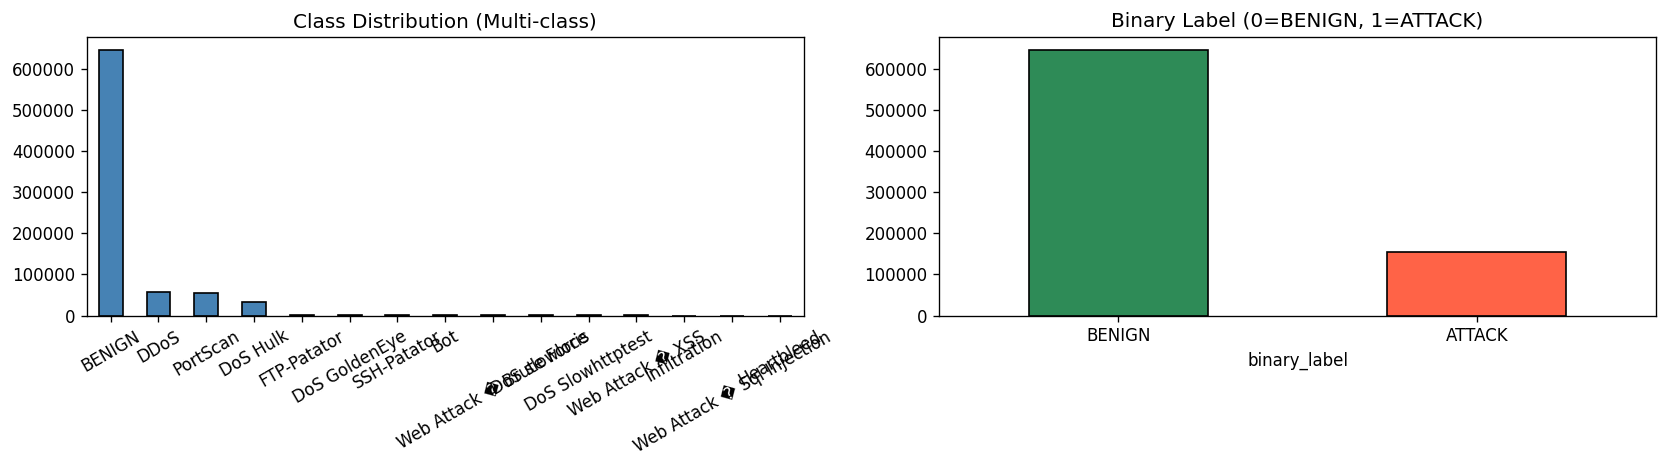

In [4]:
# Visualize class distribution
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

data[' Label' if ' Label' in data.columns else 'Label'].value_counts().plot(
    kind='bar', ax=ax1, color='steelblue', edgecolor='black')
ax1.set_title('Class Distribution (Multi-class)')
ax1.set_xlabel('')
ax1.tick_params(axis='x', rotation=30)

y.value_counts().plot(kind='bar', ax=ax2, color=['seagreen', 'tomato'], edgecolor='black')
ax2.set_title('Binary Label (0=BENIGN, 1=ATTACK)')
ax2.set_xticklabels(['BENIGN', 'ATTACK'], rotation=0)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'class_distribution.png', bbox_inches='tight')
plt.show()

## 3. Helper Functions

In [5]:
def measure_latency(model, X_test_df, n_runs=10):
    """Per-sample inference latency in ms."""
    single = X_test_df.iloc[[0]]
    lats = []
    for _ in range(n_runs):
        t0 = time.perf_counter()
        model.predict(single)
        lats.append((time.perf_counter() - t0) * 1000)
    return np.mean(lats)


def evaluate(model, X_test_df, y_test, name):
    y_pred = model.predict(X_test_df)
    if hasattr(model, 'predict_proba'):
        y_score = model.predict_proba(X_test_df)[:, 1]
    elif hasattr(model, 'decision_function'):
        y_score = model.decision_function(X_test_df)
    else:
        y_score = y_pred.astype(float)

    pr_auc  = average_precision_score(y_test, y_score)
    recall  = recall_score(y_test, y_pred)
    prec    = precision_score(y_test, y_pred)
    f1      = f1_score(y_test, y_pred)
    lat     = measure_latency(model, X_test_df)

    print(f'\n─── {name} ───')
    print(f'  PR-AUC    : {pr_auc:.4f}')
    print(f'  Recall    : {recall:.4f}')
    print(f'  Precision : {prec:.4f}')
    print(f'  F1-Score  : {f1:.4f}')
    print(f'  Latency   : {lat:.3f} ms  {"✓" if lat < LATENCY_THRESHOLD else "✗"}')

    return {
        'model': name, 'PR-AUC': pr_auc, 'Recall': recall,
        'Precision': prec, 'F1': f1, 'Latency_ms': lat,
        'meets_latency': lat < LATENCY_THRESHOLD,
        'y_pred': y_pred, 'y_score': y_score,
    }

print('✓ Helper functions defined')

✓ Helper functions defined


## 4. H1 — RF vs SVM on Full Dataset

In [6]:
scaler = StandardScaler()
X_train_sc = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns)
X_test_sc  = pd.DataFrame(scaler.transform(X_test),      columns=X_test.columns)

# Random Forest
print('Training RF...')
t0 = time.time()
rf = RandomForestClassifier(n_estimators=100, n_jobs=-1, 
                             random_state=RANDOM_STATE, class_weight='balanced')
rf.fit(X_train_sc, y_train)
print(f'RF trained in {time.time()-t0:.1f}s')

# SVM (LinearSVC is fastest for large N)
print('\nTraining LinearSVM...')
t0 = time.time()
svm = LinearSVC(C=1.0, max_iter=2000, random_state=RANDOM_STATE, class_weight='balanced')
svm.fit(X_train_sc, y_train)
print(f'SVM trained in {time.time()-t0:.1f}s')

rf_m  = evaluate(rf,  X_test_sc, y_test, 'RF (H1)')
svm_m = evaluate(svm, X_test_sc, y_test, 'LinearSVM (H1)')

results_h1 = [rf_m, svm_m]

Training RF...
RF trained in 23.9s

Training LinearSVM...
SVM trained in 158.8s

─── RF (H1) ───
  PR-AUC    : 0.9997
  Recall    : 0.9976
  Precision : 0.9962
  F1-Score  : 0.9969
  Latency   : 23.436 ms  ✓

─── LinearSVM (H1) ───
  PR-AUC    : 0.9177
  Recall    : 0.9605
  Precision : 0.6868
  F1-Score  : 0.8009
  Latency   : 0.650 ms  ✓


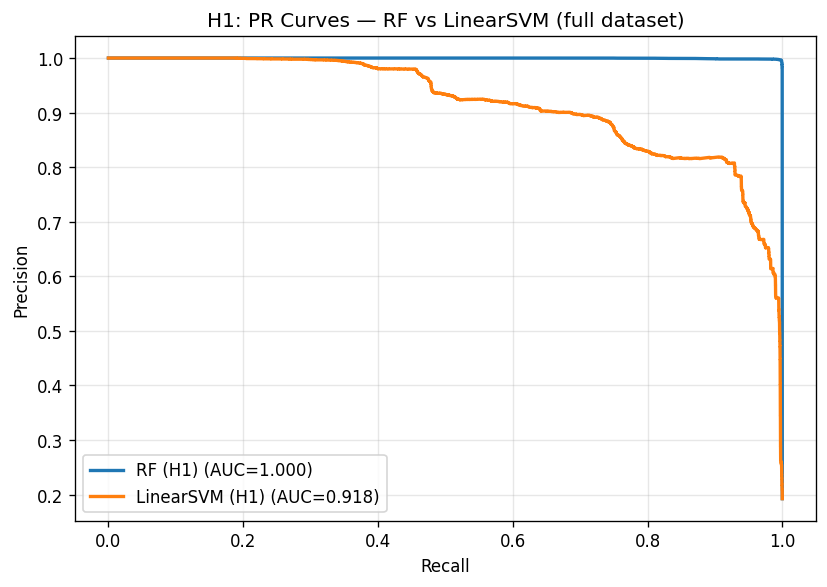

In [7]:
# PR-Curves for H1
fig, ax = plt.subplots(figsize=(7, 5))
for r in results_h1:
    p, rec, _ = precision_recall_curve(y_test, r['y_score'])
    ax.plot(rec, p, lw=2, label=f"{r['model']} (AUC={r['PR-AUC']:.3f})")
ax.set_xlabel('Recall'); ax.set_ylabel('Precision')
ax.set_title('H1: PR Curves — RF vs LinearSVM (full dataset)')
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'h1_pr_curves.png', bbox_inches='tight')
plt.show()

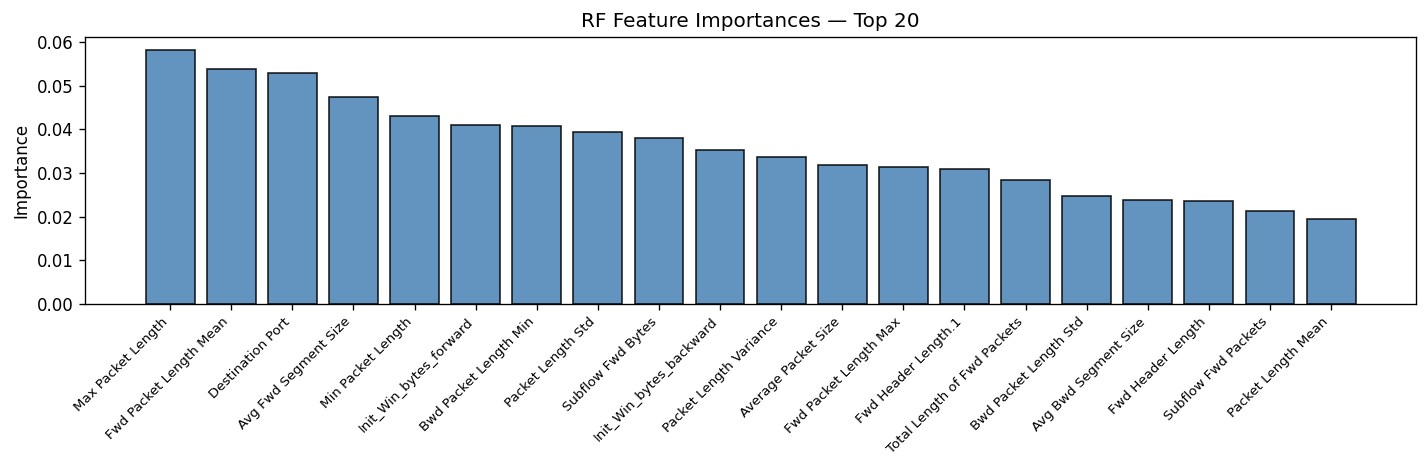

In [8]:
# Feature importance
importances = rf.feature_importances_
top20_idx = np.argsort(importances)[::-1][:20]

fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(range(20), importances[top20_idx], color='steelblue', alpha=0.85, edgecolor='black')
ax.set_xticks(range(20))
ax.set_xticklabels([X.columns[i] for i in top20_idx], rotation=45, ha='right', fontsize=8)
ax.set_title('RF Feature Importances — Top 20')
ax.set_ylabel('Importance')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'feature_importance.png', bbox_inches='tight')
plt.show()

## 5. H2 — Hybrid RF→SVM (Feature Selection + Classification)

In [9]:
TOP_K = 14

# Step 1: RF selects top-K features
top_idx = np.argsort(rf.feature_importances_)[::-1][:TOP_K]
print(f'Top-{TOP_K} features: {[X.columns[i] for i in top_idx]}')

X_train_top = X_train_sc.iloc[:, top_idx]
X_test_top  = X_test_sc.iloc[:, top_idx]

# Step 2: SVM classifier on selected features
print('\nTraining Hybrid SVM (RBF, top-14 features)...')
MAX_TRAIN = min(30_000, len(X_train_top))
idx = np.random.RandomState(RANDOM_STATE).choice(len(X_train_top), MAX_TRAIN, replace=False)

svm_hybrid = SVC(C=1.0, kernel='rbf', probability=True,
                  random_state=RANDOM_STATE, class_weight='balanced')
t0 = time.time()
svm_hybrid.fit(X_train_top.iloc[idx], y_train.iloc[idx])
print(f'Hybrid SVM trained in {time.time()-t0:.1f}s')

hybrid_m = evaluate(svm_hybrid, X_test_top, y_test, 'Hybrid RF→SVM (H2)')

Top-14 features: ['Max Packet Length', 'Fwd Packet Length Mean', 'Destination Port', 'Avg Fwd Segment Size', 'Min Packet Length', 'Init_Win_bytes_forward', 'Bwd Packet Length Min', 'Packet Length Std', 'Subflow Fwd Bytes', 'Init_Win_bytes_backward', 'Packet Length Variance', 'Average Packet Size', 'Fwd Packet Length Max', 'Fwd Header Length.1']

Training Hybrid SVM (RBF, top-14 features)...
Hybrid SVM trained in 36.8s

─── Hybrid RF→SVM (H2) ───
  PR-AUC    : 0.8490
  Recall    : 0.9669
  Precision : 0.6143
  F1-Score  : 0.7513
  Latency   : 0.816 ms  ✓


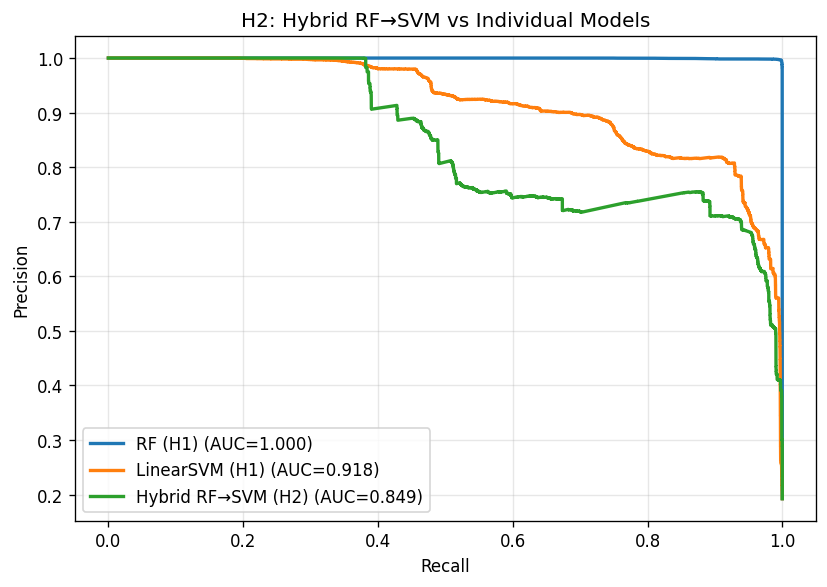

In [10]:
# Compare H2 vs H1 models
fig, ax = plt.subplots(figsize=(7, 5))
for r in [rf_m, svm_m, hybrid_m]:
    p, rec, _ = precision_recall_curve(y_test, r['y_score'])
    ax.plot(rec, p, lw=2, label=f"{r['model']} (AUC={r['PR-AUC']:.3f})")
ax.set_xlabel('Recall'); ax.set_ylabel('Precision')
ax.set_title('H2: Hybrid RF→SVM vs Individual Models')
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'h2_pr_curves.png', bbox_inches='tight')
plt.show()

## 6. H3 — SVM vs RF on Reduced Feature Set (Host-based IDS)

In [11]:
N_RED = 10   # simulate host-based IDS with fewer features

X_train_red = X_train_sc.iloc[:, :N_RED]
X_test_red  = X_test_sc.iloc[:, :N_RED]

# SVM with RBF
print(f'Training SVM-RBF on {N_RED} features...')
idx_h3 = np.random.RandomState(RANDOM_STATE).choice(len(X_train_red), min(30_000, len(X_train_red)), replace=False)
svm_h3 = SVC(C=10.0, kernel='rbf', probability=True,
              random_state=RANDOM_STATE, class_weight='balanced')
svm_h3.fit(X_train_red.iloc[idx_h3], y_train.iloc[idx_h3])
svm_h3_m = evaluate(svm_h3, X_test_red, y_test, f'SVM-RBF top-{N_RED} (H3)')

# RF on same features
print(f'\nTraining RF on {N_RED} features...')
rf_h3 = RandomForestClassifier(n_estimators=100, n_jobs=-1,
                                 random_state=RANDOM_STATE, class_weight='balanced')
rf_h3.fit(X_train_red, y_train)
rf_h3_m = evaluate(rf_h3, X_test_red, y_test, f'RF top-{N_RED} (H3)')

Training SVM-RBF on 10 features...

─── SVM-RBF top-10 (H3) ───
  PR-AUC    : 0.6644
  Recall    : 0.9395
  Precision : 0.5526
  F1-Score  : 0.6959
  Latency   : 0.889 ms  ✓

Training RF on 10 features...

─── RF top-10 (H3) ───
  PR-AUC    : 0.9965
  Recall    : 0.9895
  Precision : 0.9729
  F1-Score  : 0.9811
  Latency   : 27.562 ms  ✓


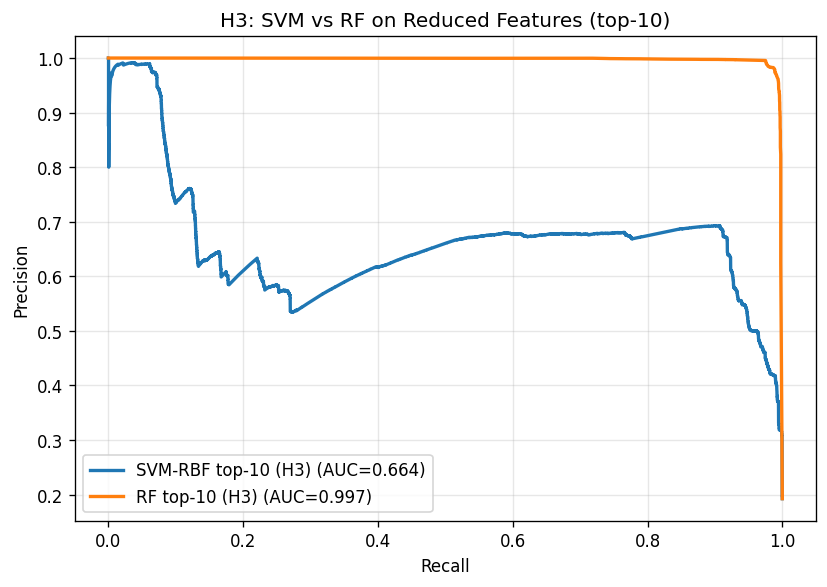

In [12]:
fig, ax = plt.subplots(figsize=(7, 5))
for r in [svm_h3_m, rf_h3_m]:
    p, rec, _ = precision_recall_curve(y_test, r['y_score'])
    ax.plot(rec, p, lw=2, label=f"{r['model']} (AUC={r['PR-AUC']:.3f})")
ax.set_xlabel('Recall'); ax.set_ylabel('Precision')
ax.set_title(f'H3: SVM vs RF on Reduced Features (top-{N_RED})')
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'h3_pr_curves.png', bbox_inches='tight')
plt.show()

## 7. Global Summary

In [13]:
all_results = [rf_m, svm_m, hybrid_m, svm_h3_m, rf_h3_m]
summary_df  = pd.DataFrame(all_results).drop(columns=['y_pred', 'y_score'], errors='ignore')
summary_df.to_csv(OUTPUT_DIR / 'results_summary.csv', index=False)
summary_df.style.background_gradient(subset=['PR-AUC', 'Recall', 'F1'], cmap='YlGn') \
               .background_gradient(subset=['Latency_ms'], cmap='RdYlGn_r')

,model,PR-AUC,Recall,Precision,F1,Latency_ms,meets_latency
0,RF (H1),0.999664,0.997629,0.996206,0.996917,23.435650,True
1,LinearSVM (H1),0.917746,0.960477,0.686832,0.800926,0.650490,True
2,Hybrid RF→SVM (H2),0.848988,0.966907,0.614307,0.751293,0.816270,True
3,SVM-RBF top-10 (H3),0.664382,0.939530,0.552553,0.695859,0.889100,True
4,RF top-10 (H3),0.996502,0.989478,0.972890,0.981114,27.562330,True


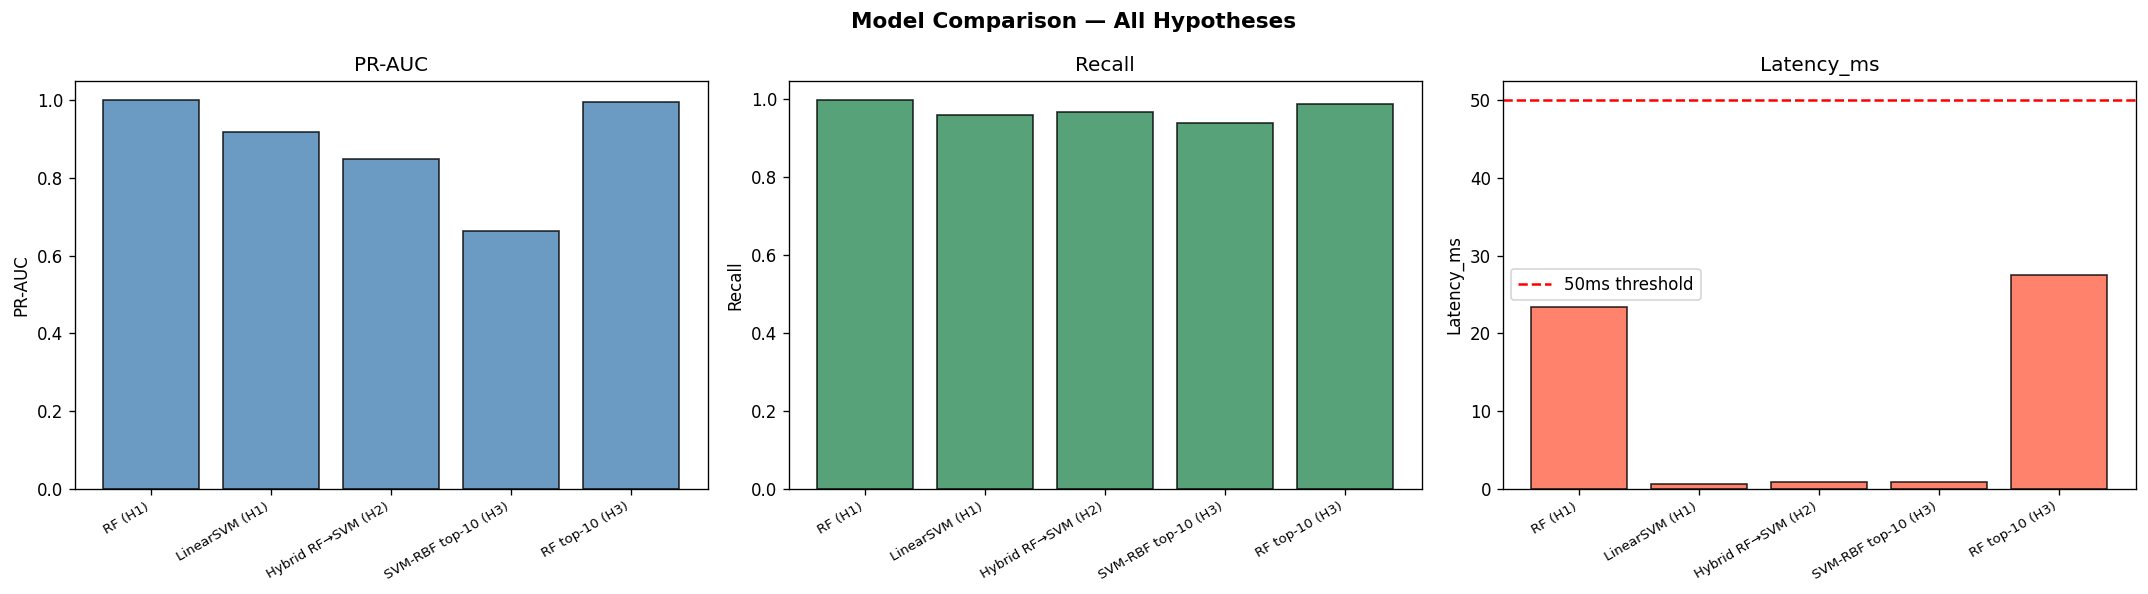

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
metrics = [('PR-AUC', 'steelblue'), ('Recall', 'seagreen'), ('Latency_ms', 'tomato')]

for ax, (metric, color) in zip(axes, metrics):
    ax.bar(summary_df['model'], summary_df[metric], color=color, alpha=0.8, edgecolor='black')
    if metric == 'Latency_ms':
        ax.axhline(50, color='red', linestyle='--', label='50ms threshold')
        ax.legend()
    ax.set_title(metric)
    ax.set_xticklabels(summary_df['model'], rotation=30, ha='right', fontsize=8)
    ax.set_ylabel(metric)

plt.suptitle('Model Comparison — All Hypotheses', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'global_comparison.png', bbox_inches='tight')
plt.show()

In [15]:
print('\n=== LATENCY CONSTRAINT (<50ms) ===')
for r in all_results:
    print(f"  {r['model']:<32} {r['Latency_ms']:.2f}ms  {'✓' if r['meets_latency'] else '✗'}")

print('\n=== PR-AUC RANKING ===')
for r in sorted(all_results, key=lambda x: x['PR-AUC'], reverse=True):
    print(f"  {r['model']:<32} PR-AUC={r['PR-AUC']:.4f}  Recall={r['Recall']:.4f}")


=== LATENCY CONSTRAINT (<50ms) ===
  RF (H1)                          23.44ms  ✓
  LinearSVM (H1)                   0.65ms  ✓
  Hybrid RF→SVM (H2)               0.82ms  ✓
  SVM-RBF top-10 (H3)              0.89ms  ✓
  RF top-10 (H3)                   27.56ms  ✓

=== PR-AUC RANKING ===
  RF (H1)                          PR-AUC=0.9997  Recall=0.9976
  RF top-10 (H3)                   PR-AUC=0.9965  Recall=0.9895
  LinearSVM (H1)                   PR-AUC=0.9177  Recall=0.9605
  Hybrid RF→SVM (H2)               PR-AUC=0.8490  Recall=0.9669
  SVM-RBF top-10 (H3)              PR-AUC=0.6644  Recall=0.9395
